In [1]:
import os
import warnings
import pickle
from itertools import product
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

# Parameters 
TICKER = "TSLA"
FIRST_PERIOD_START_DATE = "2017-01-01"
FIRST_PERIOD_END_DATE   = "2022-12-31"
SECOND_PERIOD_START_DATE = "2023-01-01"
SECOND_PERIOD_END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

BASE_DIR = f"../../data/z_hmm/{TICKER}"
os.makedirs(BASE_DIR, exist_ok=True)
MODEL_PATH = f"hmm_{TICKER}.pkl"
MD_PATH = f"hmm_{TICKER}_training_info.md"

# Hyperparameters to explore
N_COMPONENTS_CHOICES = [2, 3, 4]
MOMENTUM_DELAYS      = [5, 10, 20]
N_MOMENTUMS_CHOICES  = [1, 2, 3]

# False = long/flat & fees
USE_SHORT_CURVE = False  
FEES = 0.004

In [2]:
# Utility functions 
def download_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, interval="1d").reset_index()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns = [c.lower() for c in df.columns]
    df = df.rename(columns={"date":"timestamp"})
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df

def compute_basic_features(df):
    df = df.copy()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    df['volatility_5'] = df['log_returns'].rolling(window=5).std()
    df['momentum_5'] = df['log_returns'].rolling(window=5).mean()
    df = df.dropna(subset=['log_returns', 'volatility_5', 'momentum_5']).copy()
    return df

def build_hmm_features(df, mom_delay, n_moms):
    df = df.copy()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    features = ['log_returns']
    for k in range(n_moms):
        df[f'momentum_{k}'] = np.log(df['close'] / df['close'].shift(mom_delay + k))
        features.append(f'momentum_{k}')
    df = df.dropna(subset=features)
    return df, features

def fit_hmm(X, n_components):
    model = GaussianHMM(n_components=n_components, covariance_type="full", n_iter=10000,
                        tol=1e-4, algorithm='map', random_state=42)
    model.fit(X)
    return model

def assign_signals_by_regime(df):
    regime_means = df.groupby('market_regime')['log_returns'].mean()
    long_regime  = regime_means.idxmax()
    short_regime = regime_means.idxmin()
    signal_map = {reg: (1 if reg==long_regime else (-1 if reg==short_regime else 0)) for reg in regime_means.index}
    df['signal'] = df['market_regime'].map(signal_map)
    return df, signal_map

def predict_no_repaint(model, X_scaled):
    preds = np.empty(len(X_scaled), dtype=int)
    for i in range(len(X_scaled)):
        seq = X_scaled[:i+1]
        preds[i] = model.predict(seq)[-1]
    return preds

def build_hmm_features2(df, mom_delay, n_moms, features):
    df = df.copy()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    feats = ['log_returns']
    for k in range(n_moms):
        df[f'momentum_{k}'] = np.log(df['close'] / df['close'].shift(mom_delay + k))
        feats.append(f'momentum_{k}')
    df = df.dropna(subset=feats)
    return df, [f for f in feats if f in features]

def compute_drawdown(cumret_series):
    rolling_max = cumret_series.cummax()
    return (cumret_series - rolling_max) / rolling_max

def compute_stats(strategy_ret, benchmark_ret):
    mu_s, sd_s = strategy_ret.mean(), strategy_ret.std(ddof=0)
    sharpe = (mu_s / (sd_s + 1e-12)) * np.sqrt(365) if sd_s > 0 else 0.0
    cum_return = np.exp(strategy_ret.cumsum().iloc[-1])
    max_dd = compute_drawdown(np.exp(strategy_ret.cumsum())).min() * 100  # %
    # Alpha & Beta
    X = benchmark_ret.values.reshape(-1,1)
    y = strategy_ret.values
    reg = LinearRegression().fit(X, y)
    beta = reg.coef_[0]
    alpha = reg.intercept_ * 365
    return {'cumulative': cum_return, 'sharpe': sharpe, 'max_drawdown': max_dd, 'alpha': alpha, 'beta': beta}

In [3]:
# Download training data and compute basic features 
df_train_raw = compute_basic_features(download_data(TICKER, FIRST_PERIOD_START_DATE, FIRST_PERIOD_END_DATE))

# Walk-forward to find best hyperparameters 
n_train = len(df_train_raw)
cut = int(n_train * 0.8)
df_fit_raw = df_train_raw.iloc[:cut].copy()
df_val_raw = df_train_raw.iloc[cut:].copy()

best = {'score': -np.inf, 'params': None, 'signal_map': None, 'means': None, 'stds': None, 'features': None}

for n_comp, mom_delay, n_moms in product(N_COMPONENTS_CHOICES, MOMENTUM_DELAYS, N_MOMENTUMS_CHOICES):
    df_fit, feat = build_hmm_features(df_fit_raw, mom_delay, n_moms)
    df_val, _   = build_hmm_features(df_val_raw, mom_delay, n_moms)
    if len(df_fit) < 50 or len(df_val) < 30:
        continue

    X_fit = df_fit[feat].values
    means = np.nanmean(X_fit, axis=0)
    stds  = np.nanstd(X_fit, axis=0)
    X_fit_scaled = (X_fit - means)/(stds + 1e-8)

    try:
        model = fit_hmm(X_fit_scaled, n_comp)
    except:
        continue

    df_fit_tmp = df_fit.copy()
    df_fit_tmp['market_regime'] = model.predict(X_fit_scaled)
    df_fit_tmp, signal_map = assign_signals_by_regime(df_fit_tmp)

    X_val = df_val[feat].values
    X_val_scaled = (X_val - means)/(stds + 1e-8)
    states_val = predict_no_repaint(model, X_val_scaled)
    df_val_tmp = df_val.copy()
    df_val_tmp['market_regime'] = states_val
    df_val_tmp['signal'] = pd.Series(states_val).map(signal_map).values

    strat_rets = (df_val_tmp['signal'] == 1).astype(float) * df_val_tmp['log_returns']
    cum = float(np.exp(strat_rets.cumsum().iloc[-1]))
    mu, sd = strat_rets.mean(), strat_rets.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(252) if sd > 0 else 0.0
    score = cum + 0.05 * sharpe

    if score > best['score']:
        best.update({'score': score,
                     'params': {'n_components': n_comp, 'momentum_delay': mom_delay, 'n_momentums': n_moms},
                     'signal_map': signal_map,
                     'means': means,
                     'stds': stds,
                     'features': feat})

print("Best hyperparameters:", best['params'], "score:", round(best['score'],4))

# Retrain HMM on full training set 
mom_delay = best['params']['momentum_delay']
n_moms    = best['params']['n_momentums']
n_comp    = best['params']['n_components']

df_train_hmm, features = build_hmm_features(df_train_raw, mom_delay, n_moms)
X_train = df_train_hmm[features].values
means = np.nanmean(X_train, axis=0)
stds  = np.nanstd(X_train, axis=0)
X_train_scaled = (X_train - means)/(stds + 1e-8)
model = fit_hmm(X_train_scaled, n_comp)

states_train = model.predict(X_train_scaled)
df_train_hmm['market_regime'] = states_train
df_train_hmm, signal_map = assign_signals_by_regime(df_train_hmm)

# Save model 
to_save = {
    'model': model,
    'means': means,
    'stds': stds,
    'signal_map': signal_map,
    'features': features,
    'params': best['params']
}

with open(f"{BASE_DIR}/{MODEL_PATH}", "wb") as f:
    pickle.dump(to_save, f)

print("Model saved at", f"{BASE_DIR}/{MODEL_PATH}")

# Save training info in Markdown 
md_content = f"# HMM Model Training Information\n\n" \
             f"**Ticker:** {TICKER}\n\n" \
             f"**Training period start:** {FIRST_PERIOD_START_DATE}\n\n" \
             f"**Training period end:** {FIRST_PERIOD_END_DATE}\n\n" \
             f"**Best hyperparameters:** {best['params']}\n\n" \
             f"**Score:** {round(best['score'],4)}\n"

with open(f"{BASE_DIR}/{MD_PATH}", "w") as f:
    f.write(md_content)

print("Training information saved at", f"{BASE_DIR}/{MD_PATH}")

[*********************100%***********************]  1 of 1 completed


Best hyperparameters: {'n_components': 3, 'momentum_delay': 5, 'n_momentums': 1} score: 1.8585
Model saved at ../../data/z_hmm/TSLA/hmm_TSLA.pkl
Training information saved at ../../data/z_hmm/TSLA/hmm_TSLA_training_info.md


[*********************100%***********************]  1 of 1 completed


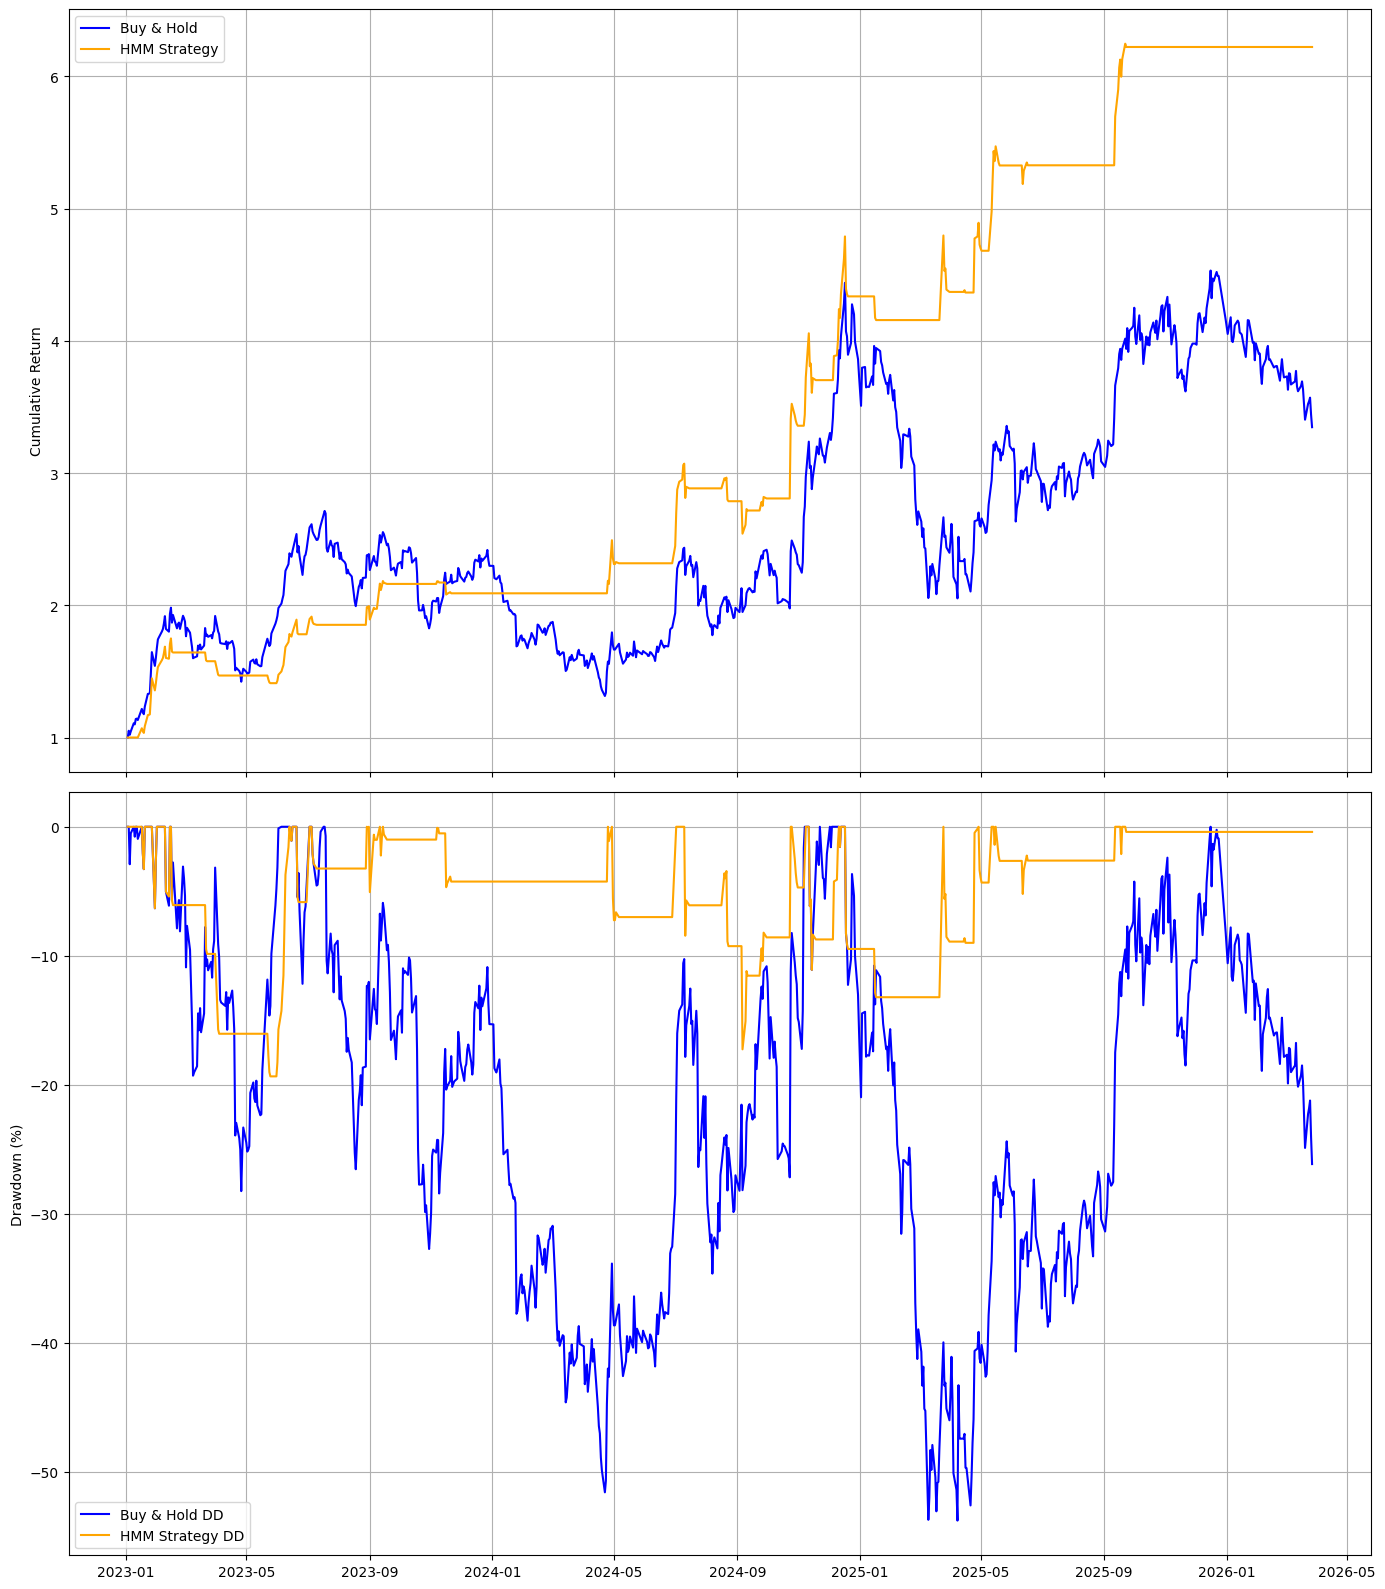

In [4]:

# Load model 
with open(f"{BASE_DIR}/{MODEL_PATH}", "rb") as f:
    saved = pickle.load(f)

model = saved['model']
means = saved['means']
stds = saved['stds']
signal_map = saved['signal_map']
features = saved['features']
params = saved.get('params', {})

# Download test data 
df_test_raw = download_data(TICKER, SECOND_PERIOD_START_DATE, SECOND_PERIOD_END_DATE)

# Build HMM features 
mom_delay = params['momentum_delay']
n_moms = params['n_momentums']
df_test_hmm, used_features = build_hmm_features2(df_test_raw, mom_delay, n_moms, features)

X_test = df_test_hmm[used_features].values
X_test_scaled = (X_test - means) / (stds + 1e-8)
states_test = predict_no_repaint(model, X_test_scaled)

df_test_hmm['market_regime'] = states_test
df_test_hmm['signal'] = pd.Series(states_test).map(signal_map).values

# Merging with raw data 
df = df_test_raw.merge(
    df_test_hmm[['timestamp', 'market_regime', 'signal']],
    on='timestamp', how='left'
)
df['signal'] = df['signal'].fillna(0)
df['market_regime'] = df['market_regime'].fillna(-1).astype(int)

# Position according to strategy 
df['position'] = (df['signal'] == 1).astype(float) if not USE_SHORT_CURVE else df['signal'].clip(-1,1).astype(float)

# Daily yields 
df['log_returns'] = np.log(df['close']/df['close'].shift(1))
df['log_returns'].fillna(0, inplace=True)

# Transaction costs 
pos_change = df['position'].diff().fillna(0.0)
fees_series = np.abs(pos_change) * FEES

# Strategy performance 
df['strategy_log_ret'] = df['position']*df['log_returns'] - fees_series

# Cumulatif returns 
df['strategy_cumret'] = np.exp(df['strategy_log_ret'].cumsum())
df['bh_cumret'] = np.exp(df['log_returns'].cumsum())
df['strategy_dd'] = compute_drawdown(df['strategy_cumret'])
df['bh_dd'] = compute_drawdown(df['bh_cumret'])

# Statistics 
stats_strategy = compute_stats(df['strategy_log_ret'], df['log_returns'])
stats_bh = compute_stats(df['log_returns'], df['log_returns'])

# Transaction counting 
n_achats = (pos_change > 0).sum()
n_ventes = (pos_change < 0).sum()

# Plot 
fig, axes = plt.subplots(2,1, figsize=(14,16), sharex=True)

# Cumulatif returns
axes[0].plot(df['timestamp'], df['bh_cumret'], label="Buy & Hold", color='blue')
axes[0].plot(df['timestamp'], df['strategy_cumret'], label="HMM Strategy", color='orange')
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True)

# Drawdown
axes[1].plot(df['timestamp'], df['bh_dd']*100, label="Buy & Hold DD", color='blue')
axes[1].plot(df['timestamp'], df['strategy_dd']*100, label="HMM Strategy DD", color='orange')
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
# Time spent in position (as a percentage of the time)
total_days = len(df)
position_days = (df['position'] > 0).sum()
pct_time_in_position = (position_days / total_days) * 100

# Total performance over the period (in %, based on cumulative totals)
perf_bh_percent = (df['bh_cumret'].iloc[-1] - 1.0) * 100
perf_hmm_percent = (df['strategy_cumret'].iloc[-1] - 1.0) * 100

# Annualized return in %
mu_bh = df['log_returns'].mean()
mu_strategy = df['strategy_log_ret'].mean()

annual_return_bh = (np.exp(mu_bh * 365) - 1) * 100
annual_return_hmm = (np.exp(mu_strategy * 365) - 1) * 100

# Summary table
table = pd.DataFrame({
    "Métrique": [
        "Total performance over the period (%)",
        "Annualized return (%)",
        "Max drawdown (%)",
        "Sharpe ratio",
        "Beta",
        "Alpha",
        "Number of trades",
        "% time in position",
    ],
    "Buy & Hold": [
        perf_bh_percent,
        annual_return_bh,
        stats_bh["max_drawdown"],
        stats_bh["sharpe"],
        "-",
        "-",
        1,
        100,
    ],
    "HMM Strategy": [
        perf_hmm_percent,
        annual_return_hmm,
        stats_strategy["max_drawdown"],
        stats_strategy["sharpe"],
        stats_strategy["beta"],
        stats_strategy["alpha"],
        n_achats + n_ventes,
        pct_time_in_position,
    ],
})

# Well formatted display
pd.set_option("display.float_format", "{:.4g}".format)
print("\n" + "="*70)
print(" COMPARISON OF HMM STRATEGY VS BUY & HOLD".center(70))
print("="*70)
print(table)


               COMPARISON OF HMM STRATEGY VS BUY & HOLD               
                                Métrique Buy & Hold  HMM Strategy
0  Total performance over the period (%)      234.7         522.3
1                  Annualized return (%)      72.24         127.7
2                       Max drawdown (%)     -53.77        -19.34
3                           Sharpe ratio     0.7778         2.245
4                                   Beta          -         0.279
5                                  Alpha          -        0.6711
6                       Number of trades          1            54
7                     % time in position        100         16.65
